In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

# Path to Downloads folder
downloads_path = os.path.join(os.path.expanduser('~'), 'Downloads')

# Your exact filename
file_name = 'Working_Cleaned_RIT_Opportunity_Data'
file_path = os.path.join(downloads_path, file_name)

# Try different extensions
import os
if os.path.exists(file_path + '.csv'):
    df = pd.read_csv(file_path + '.csv')
    print("✅ Loaded CSV file")
elif os.path.exists(file_path + '.xlsx'):
    df = pd.read_excel(file_path + '.xlsx')
    print("✅ Loaded Excel file")
else:
    # Check what files are in Downloads
    print("File not found. Here are files in Downloads:")
    for f in os.listdir(downloads_path):
        if 'RIT' in f or 'Opportunity' in f or 'Working' in f:
            print(f"  - {f}")
    # If not found, print all files
    print("\nAll files in Downloads:")
    for f in os.listdir(downloads_path):
        print(f"  - {f}")

# Display basic info
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Loaded CSV file

Dataset shape: (8547, 26)
Columns: ['Unnamed: 0', 'Learner SignUp DateTime', 'Opportunity Id', 'Opportunity Name', 'Opportunity Category', 'Opportunity End Date', 'First Name', 'Date of Birth', 'Gender', 'Country', 'Institution Name', 'Current/Intended Major', 'Entry created at', 'Status Description', 'Status Code', 'Apply Date', 'Opportunity Start Date', 'Age', 'Age_Flag', 'Days_Signup_to_Apply', 'Signup_Year', 'Signup_Month', 'Apps_Per_Student', 'Target_Success', 'Gender_Encoded', 'Category_Encoded']


In [2]:
# Convert dates
df['Signup_Date'] = pd.to_datetime(df['Learner SignUp DateTime'], errors='coerce')
df['Apply_Date'] = pd.to_datetime(df['Apply Date'], errors='coerce')
df['DOB'] = pd.to_datetime(df['Date of Birth'], errors='coerce')

# Calculate Age (as of 2024)
df['Age'] = (pd.Timestamp('2024-01-01') - df['DOB']).dt.days // 365

# Time to Apply (days between signup and application)
df['Days_Signup_to_Apply'] = (df['Apply_Date'] - df['Signup_Date']).dt.days

# Apps per student
df['Apps_Per_Student'] = df.groupby('First Name')['First Name'].transform('count')

# Signup Year and Month
df['Signup_Year'] = df['Signup_Date'].dt.year
df['Signup_Month'] = df['Signup_Date'].dt.month

# Encode Gender
gender_map = {'Male': 0, 'Female': 1, "Don't want to specify": 2, 'Other': 3}
df['Gender_Encoded'] = df['Gender'].map(gender_map)

# Encode Opportunity Category
cat_map = {'Internship': 0, 'Course': 1, 'Event': 2, 'Competition': 3, 'Engagement': 4}
df['Category_Encoded'] = df['Opportunity Category'].map(cat_map)

# Create Region column from Country
def get_region(country):
    us_countries = ['United States', 'Canada']
    sa_countries = ['India', 'Pakistan', 'Bangladesh', 'Nepal', 'Sri Lanka']
    africa_countries = ['Nigeria', 'Ghana', 'Kenya', 'Ethiopia', 'Rwanda', 'Uganda', 'South Africa', 
                        'Tanzania', 'Zimbabwe', 'Cameroon', 'Liberia', 'Somalia', 'Egypt', 'Morocco', 
                        'Tunisia', 'Algeria']
    
    if country in us_countries:
        return 'North America'
    elif country in sa_countries:
        return 'South Asia'
    elif country in africa_countries:
        return 'Africa'
    else:
        return 'Other'

df['Region'] = df['Country'].apply(get_region)
region_map = {'North America': 0, 'South Asia': 1, 'Africa': 2, 'Other': 3}
df['Region_Encoded'] = df['Region'].map(region_map)

# Target variable - Success (as defined in Week 2)
success_statuses = ['Started', 'Team Allocated', 'Rewards Award']
df['Target_Success'] = df['Status Description'].isin(success_statuses).astype(int)

print(f"Target distribution:\n{df['Target_Success'].value_counts(normalize=True)}")

Target distribution:
Target_Success
0    0.524395
1    0.475605
Name: proportion, dtype: float64


In [3]:
# Features selected based on Week 2 correlation analysis
feature_columns = [
    'Category_Encoded',      # Strongest predictor
    'Region_Encoded',        # Geographic effect
    'Gender_Encoded',        # Demographic
    'Age',                   # Demographic
    'Days_Signup_to_Apply',  # Engagement speed
    'Apps_Per_Student',      # Engagement level
    'Signup_Month',          # Seasonal effect
    'Signup_Year'            # Cohort effect
]

# Drop rows with missing values
model_df = df[feature_columns + ['Target_Success']].dropna()
X = model_df[feature_columns]
y = model_df['Target_Success']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Features shape: (7984, 8)
Target distribution:
Target_Success
0    0.521794
1    0.478206
Name: proportion, dtype: float64


In [4]:
# Train-test split (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} records")
print(f"Test set: {X_test.shape[0]} records")

Training set: 6387 records
Test set: 1597 records


In [5]:
# Train Multiple Models (Including KNN & Decision Tree)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize models (now with KNN and Decision Tree)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Train and evaluate
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
print("\n=== Model Performance ===\n")
print(results_df.round(4))


=== Model Performance ===

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8560     0.9120  0.7736    0.8371   0.8985
1                  KNN    0.8347     0.8521  0.7919    0.8209   0.9000
2        Decision Tree    0.8528     0.9038  0.7749    0.8344   0.9128
3        Random Forest    0.8447     0.8477  0.8233    0.8353   0.9194
4              XGBoost    0.8610     0.9169  0.7801    0.8430   0.9296


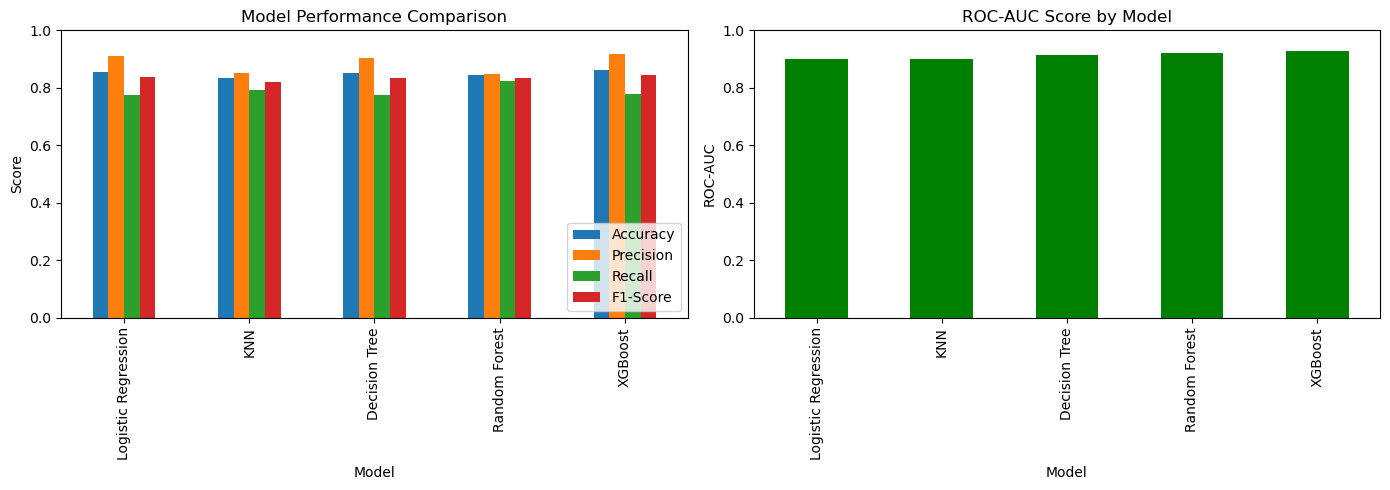

In [6]:
# Model Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_df.set_index('Model')[metrics].plot(kind='bar', ax=axes[0])
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')

results_df.set_index('Model')['ROC-AUC'].plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('ROC-AUC Score by Model')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

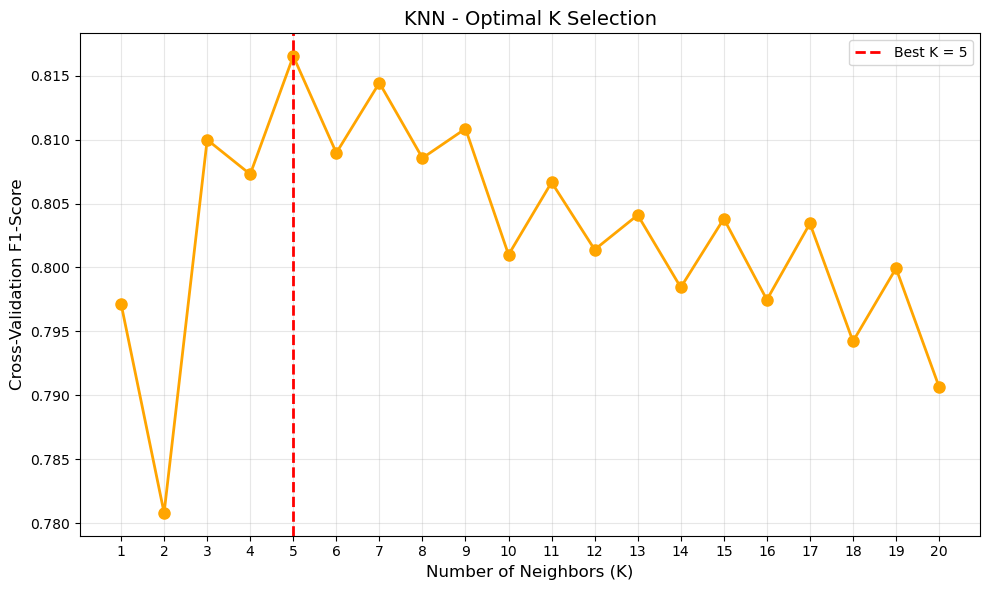


Best K value: 5
Best CV F1-Score: 0.8165


In [7]:
# KNN - Optimal K Selection
from sklearn.model_selection import cross_val_score

# Test different K values
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')
    cv_scores.append(scores.mean())

# Plot K vs. CV Score
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='orange', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Cross-Validation F1-Score', fontsize=12)
plt.title('KNN - Optimal K Selection', fontsize=14)
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.axvline(x=np.argmax(cv_scores) + 1, color='red', linestyle='--', linewidth=2,
            label=f'Best K = {np.argmax(cv_scores) + 1}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest K value: {np.argmax(cv_scores) + 1}")
print(f"Best CV F1-Score: {max(cv_scores):.4f}")

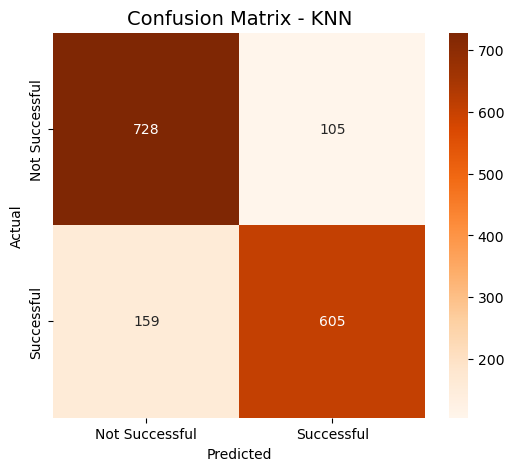


=== KNN Confusion Matrix Statistics ===

Confusion Matrix:
[[728 105]
 [159 605]]

True Negatives (correctly predicted NOT Successful): 728
False Positives (predicted Successful, but NOT): 105
False Negatives (predicted NOT Successful, but WAS): 159
True Positives (correctly predicted Successful): 605

Accuracy: 0.8347
Precision: 0.8521
Recall: 0.7919
F1-Score: 0.8209


In [10]:
# Confusion Matrix - KNN (Separate)

# Get the KNN model
knn_model = models['KNN']

# Predict on test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Generate confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.title('Confusion Matrix - KNN', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print detailed statistics
print("\n=== KNN Confusion Matrix Statistics ===\n")
print(f"Confusion Matrix:\n{cm_knn}")
print(f"\nTrue Negatives (correctly predicted NOT Successful): {cm_knn[0][0]}")
print(f"False Positives (predicted Successful, but NOT): {cm_knn[0][1]}")
print(f"False Negatives (predicted NOT Successful, but WAS): {cm_knn[1][0]}")
print(f"True Positives (correctly predicted Successful): {cm_knn[1][1]}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")

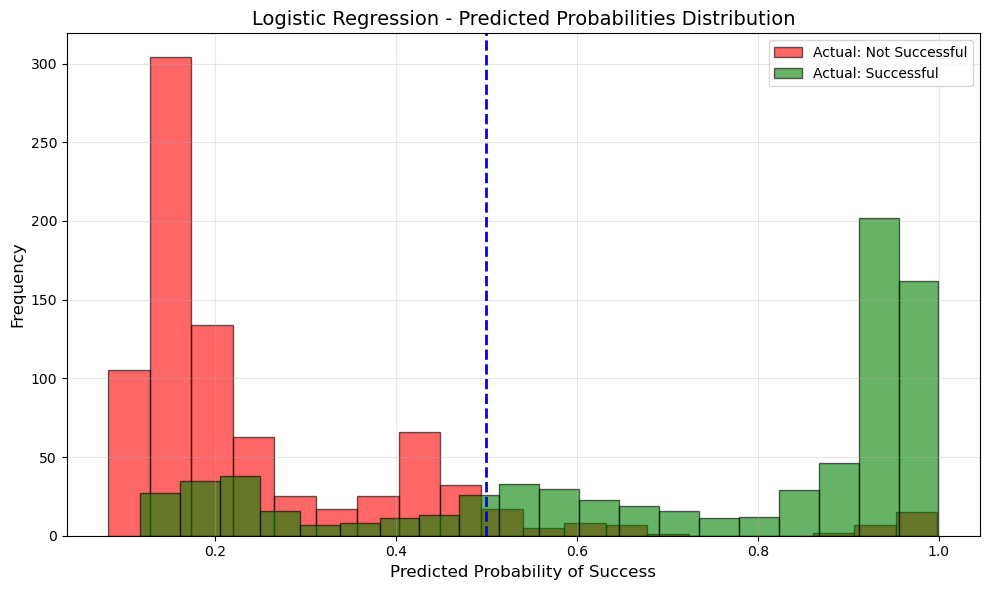


=== Interpretation ===

Good separation = model is working well
Green bars should be on the right (high probability)
Red bars should be on the left (low probability)


In [11]:
# Logistic Regression - Predicted Probabilities Distribution
lr_model = models['Logistic Regression']

# Get predicted probabilities
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(10, 6))

# Histogram for actual Not Successful students
plt.hist(y_proba_lr[y_test == 0], bins=20, alpha=0.6, 
         label='Actual: Not Successful', color='red', edgecolor='black')

# Histogram for actual Successful students
plt.hist(y_proba_lr[y_test == 1], bins=20, alpha=0.6, 
         label='Actual: Successful', color='green', edgecolor='black')

plt.xlabel('Predicted Probability of Success', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Logistic Regression - Predicted Probabilities Distribution', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
plt.tight_layout()
plt.show()

print("\n=== Interpretation ===\n")
print("Good separation = model is working well")
print("Green bars should be on the right (high probability)")
print("Red bars should be on the left (low probability)")

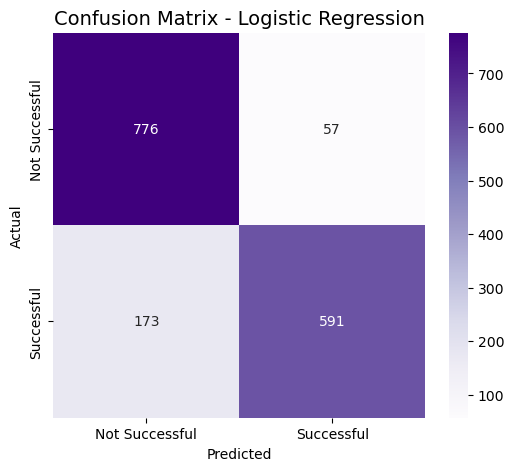


=== Logistic Regression Confusion Matrix Statistics ===

Confusion Matrix:
[[776  57]
 [173 591]]

True Negatives (correctly predicted NOT Successful): 776
False Positives (predicted Successful, but NOT): 57
False Negatives (predicted NOT Successful, but WAS): 173
True Positives (correctly predicted Successful): 591

Accuracy: 0.8560
Precision: 0.9120
Recall: 0.7736
F1-Score: 0.8371


In [12]:
# Step: Confusion Matrix - Logistic Regression (Separate)

# Get the Logistic Regression model
lr_model = models['Logistic Regression']

# Predict on test set
y_pred_lr = lr_model.predict(X_test_scaled)

# Generate confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print detailed statistics
print("\n=== Logistic Regression Confusion Matrix Statistics ===\n")
print(f"Confusion Matrix:\n{cm_lr}")
print(f"\nTrue Negatives (correctly predicted NOT Successful): {cm_lr[0][0]}")
print(f"False Positives (predicted Successful, but NOT): {cm_lr[0][1]}")
print(f"False Negatives (predicted NOT Successful, but WAS): {cm_lr[1][0]}")
print(f"True Positives (correctly predicted Successful): {cm_lr[1][1]}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

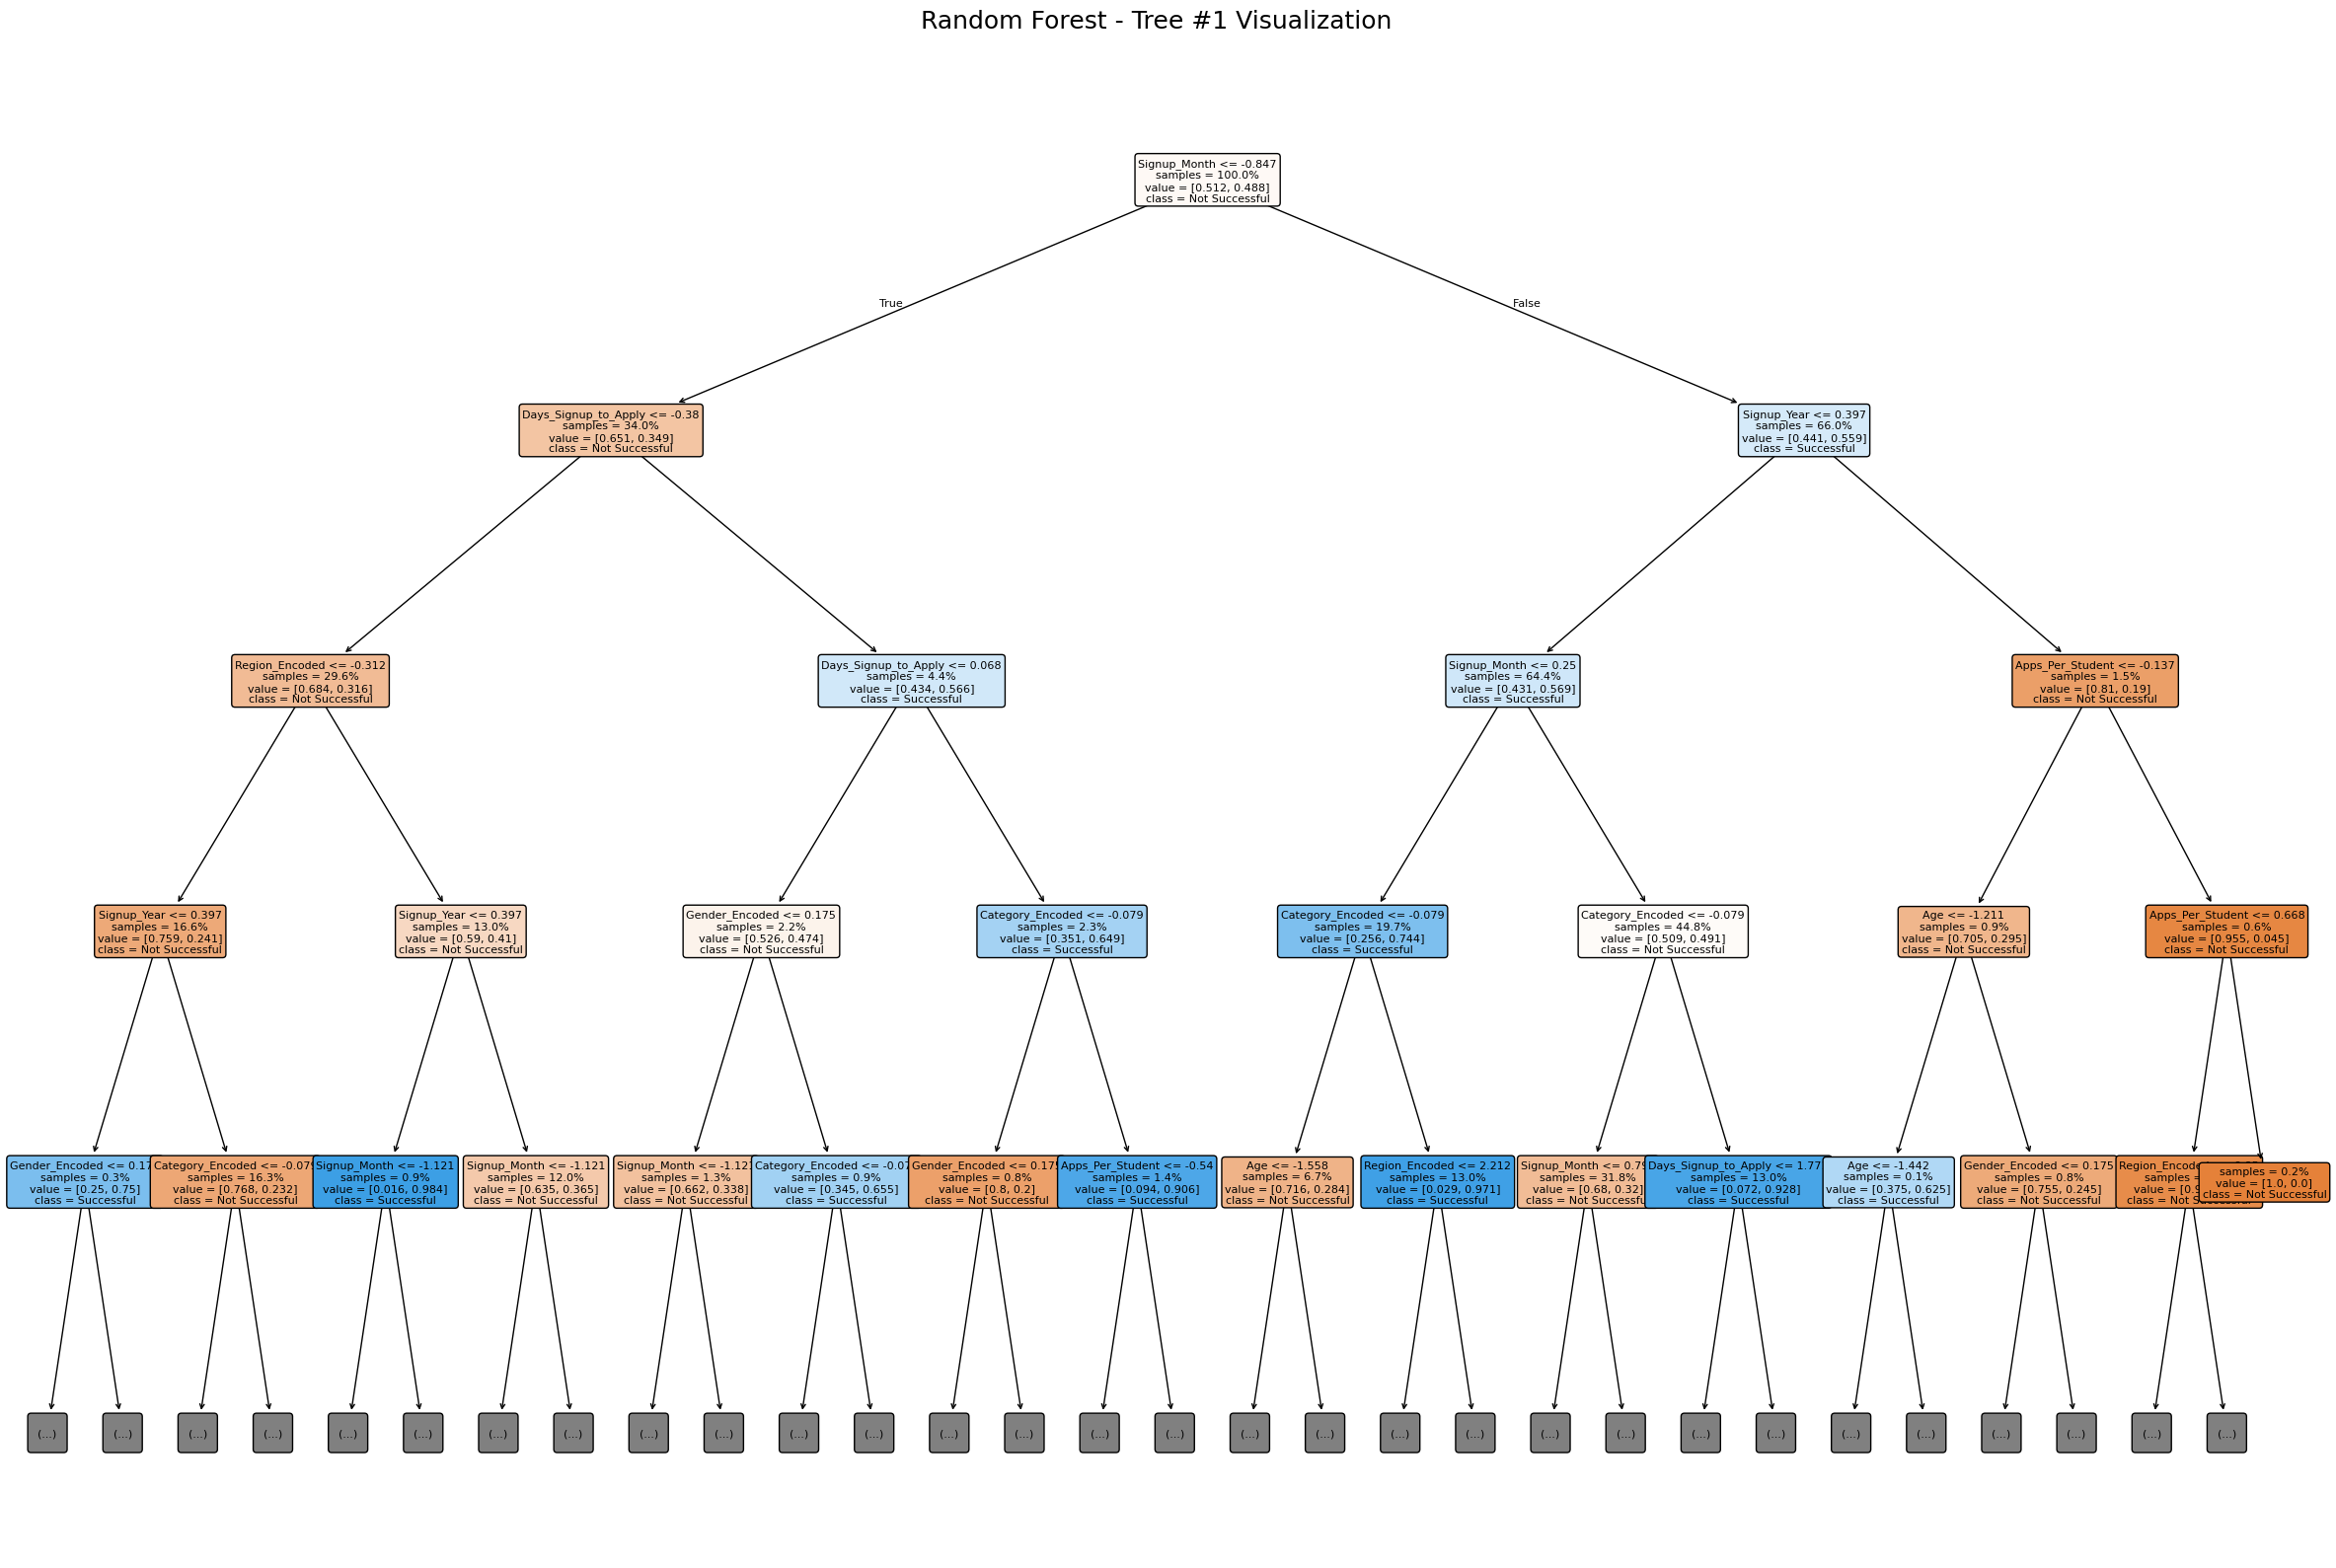

In [13]:
# Visualize a Single Tree from Random Forest
from sklearn.tree import plot_tree

# Get the Random Forest model
rf_model = models['Random Forest']

# Select the first tree from the forest (you can change index to see others)
tree_index = 0  # Try 0, 1, 2, 3, 4 to see different trees
single_tree = rf_model.estimators_[tree_index]

# Create figure
plt.figure(figsize=(24, 16))

# Plot the selected tree
plot_tree(
    single_tree,
    feature_names=feature_columns,
    class_names=['Not Successful', 'Successful'],
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True,
    max_depth=4,  # Show first 4 levels (adjust as needed)
    impurity=False
)

plt.title(f'Random Forest - Tree #{tree_index+1} Visualization', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

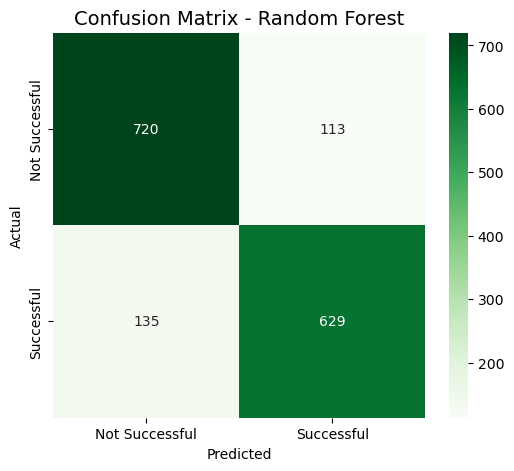


=== Random Forest Confusion Matrix Statistics ===

Confusion Matrix:
[[720 113]
 [135 629]]

True Negatives (correctly predicted NOT Successful): 720
False Positives (predicted Successful, but NOT): 113
False Negatives (predicted NOT Successful, but WAS): 135
True Positives (correctly predicted Successful): 629

Accuracy: 0.8447
Precision: 0.8477
Recall: 0.8233
F1-Score: 0.8353


In [14]:
# Confusion Matrix - Random Forest
# Get the Random Forest model
rf_model = models['Random Forest']

# Predict on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Generate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print detailed statistics
print("\n=== Random Forest Confusion Matrix Statistics ===\n")
print(f"Confusion Matrix:\n{cm_rf}")
print(f"\nTrue Negatives (correctly predicted NOT Successful): {cm_rf[0][0]}")
print(f"False Positives (predicted Successful, but NOT): {cm_rf[0][1]}")
print(f"False Negatives (predicted NOT Successful, but WAS): {cm_rf[1][0]}")
print(f"True Positives (correctly predicted Successful): {cm_rf[1][1]}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

In [15]:
# XGBoost Tree - Structured Text View
xgb_model = models['XGBoost']
booster = xgb_model.get_booster()

# Get tree dump
tree_text = booster.get_dump()[0]

print("=== XGBoost Tree #1 (Structured View) ===\n")

# Parse and format the tree
lines = tree_text.split('\n')
indent = 0
for line in lines:
    if 'yes=' in line:
        print('  ' * indent + '├── ' + line.strip())
        indent += 1
    elif 'leaf' in line:
        print('  ' * indent + '└── ' + line.strip())
        indent -= 1
    else:
        print('  ' * indent + line.strip())

# Show feature names mapping
print("\n=== Feature Index Mapping ===")
for i, feature in enumerate(feature_columns):
    print(f"f{i}: {feature}")

=== XGBoost Tree #1 (Structured View) ===

├── 0:[f0<0.462258816] yes=1,no=2,missing=2
  ├── 1:[f7<1.47299933] yes=3,no=4,missing=4
    ├── 3:[f4<0.734497607] yes=7,no=8,missing=8
      ├── 7:[f6<0.935297728] yes=15,no=16,missing=16
        ├── 15:[f5<-0.607496917] yes=31,no=32,missing=32
          ├── 31:[f4<-0.363609374] yes=55,no=56,missing=56
            └── 55:leaf=0.0512577184
          └── 56:leaf=-0.0227878448
        ├── 32:[f3<-1.0960623] yes=57,no=58,missing=58
          └── 57:leaf=0.101782821
        └── 58:leaf=-0.0528253205
      ├── 16:[f3<-1.3268522] yes=33,no=34,missing=34
        ├── 33:[f6<1.48377562] yes=59,no=60,missing=60
          └── 59:leaf=0.098205708
        └── 60:leaf=-0.0748470277
      ├── 34:[f3<0.288677096] yes=61,no=62,missing=62
        └── 61:leaf=-0.0946959853
      └── 62:leaf=-0.0543130413
    ├── 8:[f6<0.935297728] yes=17,no=18,missing=18
      ├── 17:[f4<1.2723459] yes=35,no=36,missing=36
        ├── 35:[f6<0.661058784] yes=63,no=64,missing=64


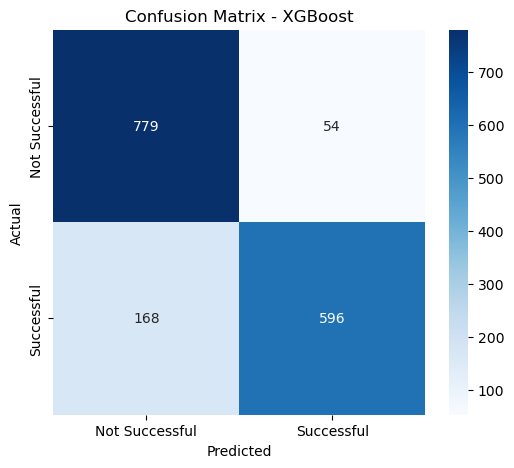


=== XGBoost Confusion Matrix Statistics ===

Confusion Matrix:
[[779  54]
 [168 596]]

True Negatives (correctly predicted NOT Successful): 779
False Positives (predicted Successful, but NOT): 54
False Negatives (predicted NOT Successful, but WAS): 168
True Positives (correctly predicted Successful): 596

Accuracy: 0.8610
Precision: 0.9169
Recall: 0.7801
F1-Score: 0.8430
ROC-AUC: 0.9296


In [16]:
# Confusion Matrix (Best Model)
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print detailed statistics
print(f"\n=== {best_model_name} Confusion Matrix Statistics ===\n")

print(f"Confusion Matrix:\n{cm}")

print(f"\nTrue Negatives (correctly predicted NOT Successful): {cm[0][0]}")
print(f"False Positives (predicted Successful, but NOT): {cm[0][1]}")
print(f"False Negatives (predicted NOT Successful, but WAS): {cm[1][0]}")
print(f"True Positives (correctly predicted Successful): {cm[1][1]}")

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:,1]):.4f}")

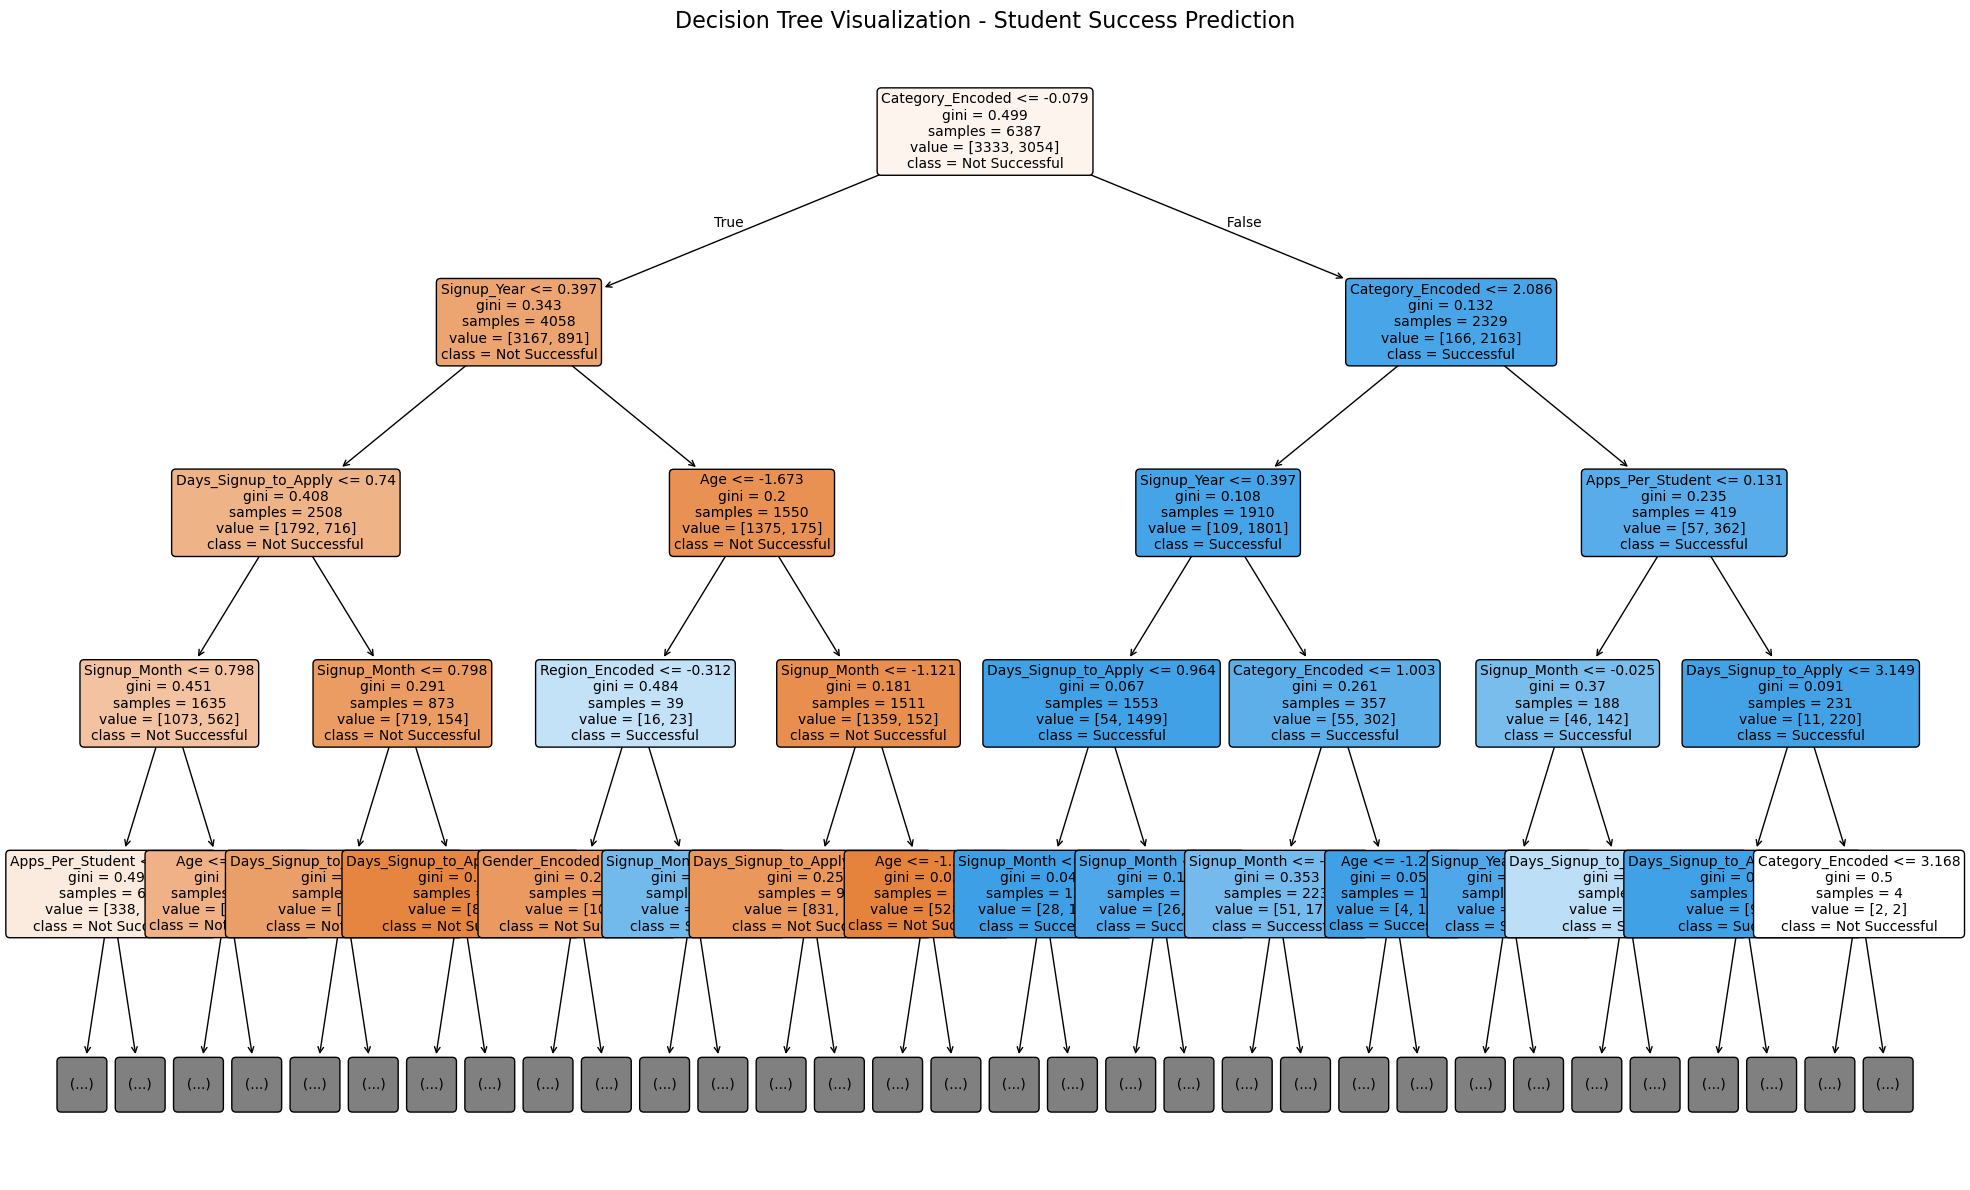

In [17]:
# Visualize Decision Tree (The "Big Tree with Branches")
plt.figure(figsize=(20, 12))
plot_tree(
    models['Decision Tree'],
    feature_names=feature_columns,
    class_names=['Not Successful', 'Successful'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=4  # Shows first 4 levels for readability
)
plt.title('Decision Tree Visualization - Student Success Prediction', fontsize=16)
plt.tight_layout()
plt.show()

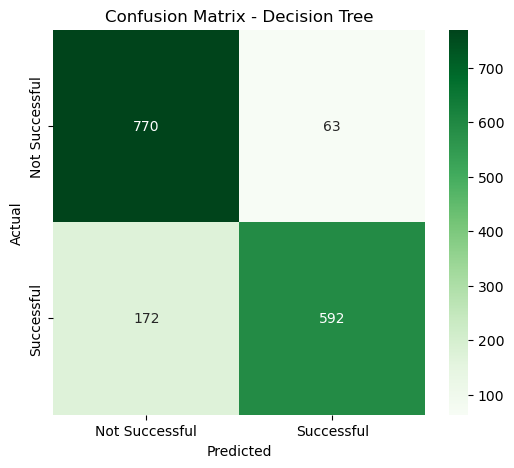


=== Decision Tree Confusion Matrix Statistics ===

Confusion Matrix:
[[770  63]
 [172 592]]

True Negatives (correctly predicted NOT Successful): 770
False Positives (predicted Successful, but NOT): 63
False Negatives (predicted NOT Successful, but WAS): 172
True Positives (correctly predicted Successful): 592

Accuracy: 0.8528
Precision: 0.9038
Recall: 0.7749
F1-Score: 0.8344


In [18]:
# Confusion Matrix - Decision Tree
dt_model = models['Decision Tree']
y_pred_dt = dt_model.predict(X_test_scaled)

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print detailed statistics
print("\n=== Decision Tree Confusion Matrix Statistics ===\n")
print(f"Confusion Matrix:\n{cm_dt}")

print(f"\nTrue Negatives (correctly predicted NOT Successful): {cm_dt[0][0]}")
print(f"False Positives (predicted Successful, but NOT): {cm_dt[0][1]}")
print(f"False Negatives (predicted NOT Successful, but WAS): {cm_dt[1][0]}")
print(f"True Positives (correctly predicted Successful): {cm_dt[1][1]}")

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")

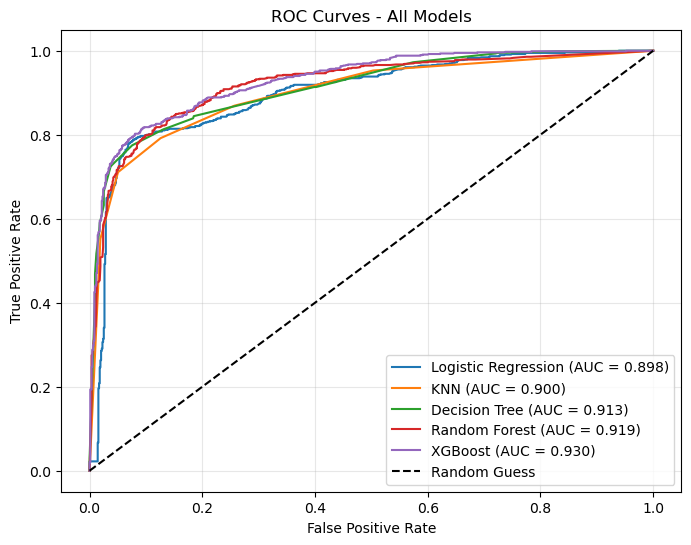

In [19]:
#  ROC Curve
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10728\2238436598.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pred_df, x='Category', y='Predicted_Probability', palette='Set2')


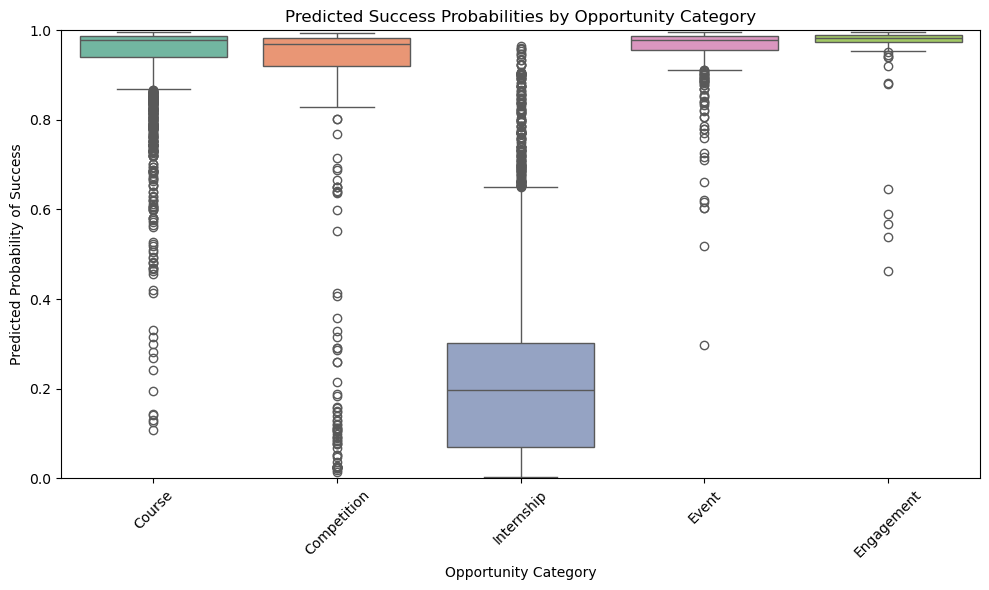

In [20]:
# Predicted Probabilities Heatmap by Opportunity Category

# Get predicted probabilities for all records
X_all_scaled = scaler.transform(X)
proba_all = best_model.predict_proba(X_all_scaled)[:, 1]

# Create DataFrame with predictions and categories
pred_df = X.copy()
pred_df['Predicted_Probability'] = proba_all
pred_df['Actual_Success'] = y
pred_df['Category'] = df.loc[pred_df.index, 'Opportunity Category']

# Box plot of predicted probabilities by category
plt.figure(figsize=(10, 6))
sns.boxplot(data=pred_df, x='Category', y='Predicted_Probability', palette='Set2')
plt.title('Predicted Success Probabilities by Opportunity Category')
plt.xlabel('Opportunity Category')
plt.ylabel('Predicted Probability of Success')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

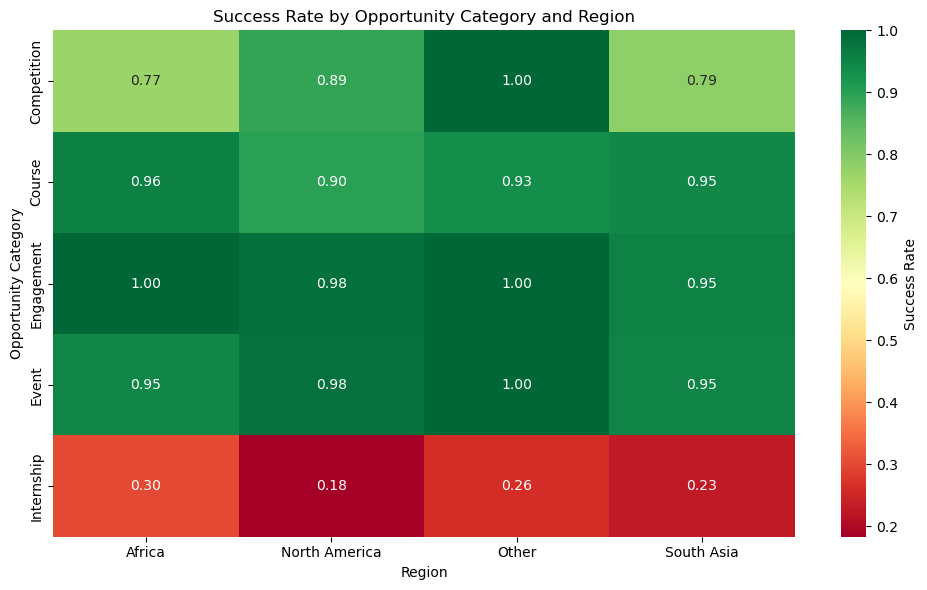

In [21]:
# Heatmap - Success Rate by Category and Region
category_region_success = pd.crosstab(
    df['Opportunity Category'], 
    df['Region'],
    values=df['Target_Success'],
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(category_region_success, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={'label': 'Success Rate'})
plt.title('Success Rate by Opportunity Category and Region')
plt.xlabel('Region')
plt.ylabel('Opportunity Category')
plt.tight_layout()
plt.show()

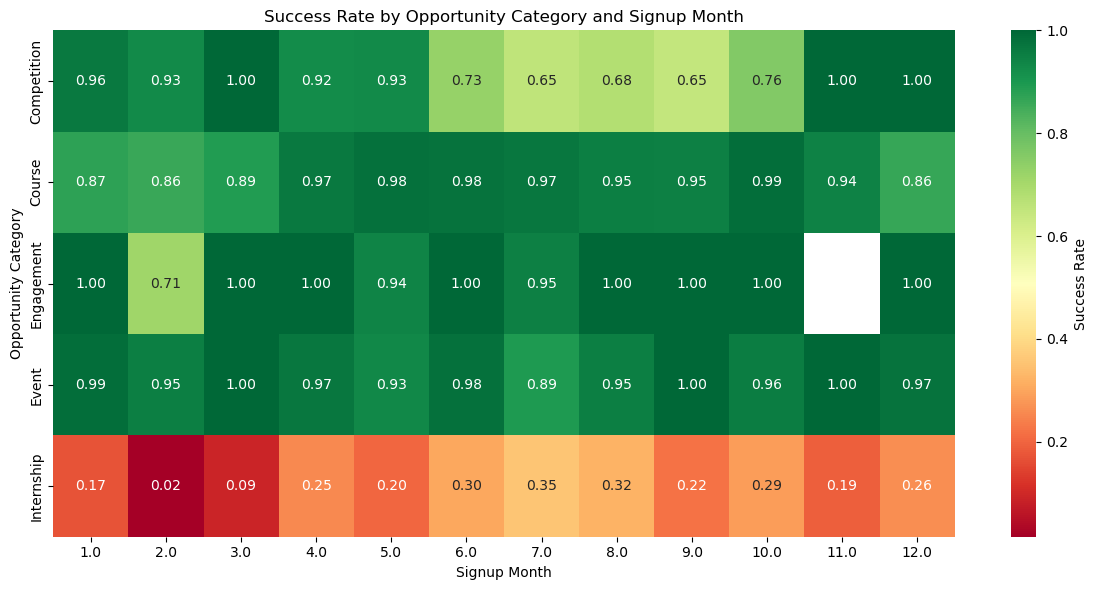

In [22]:
# Heatmap - Success Probability by Category and Signup Month
category_month_success = pd.crosstab(
    df['Opportunity Category'],
    df['Signup_Month'],
    values=df['Target_Success'],
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(category_month_success, annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': 'Success Rate'})
plt.title('Success Rate by Opportunity Category and Signup Month')
plt.xlabel('Signup Month')
plt.ylabel('Opportunity Category')
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10728\827392663.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance, x='Importance', y='Feature', ax=axes[0], palette='viridis')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10728\827392663.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dt_importance, x='Importance', y='Feature', ax=axes[1], palette='Blues_d')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10728\827392663.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_importance, x='Importance', y='Featu

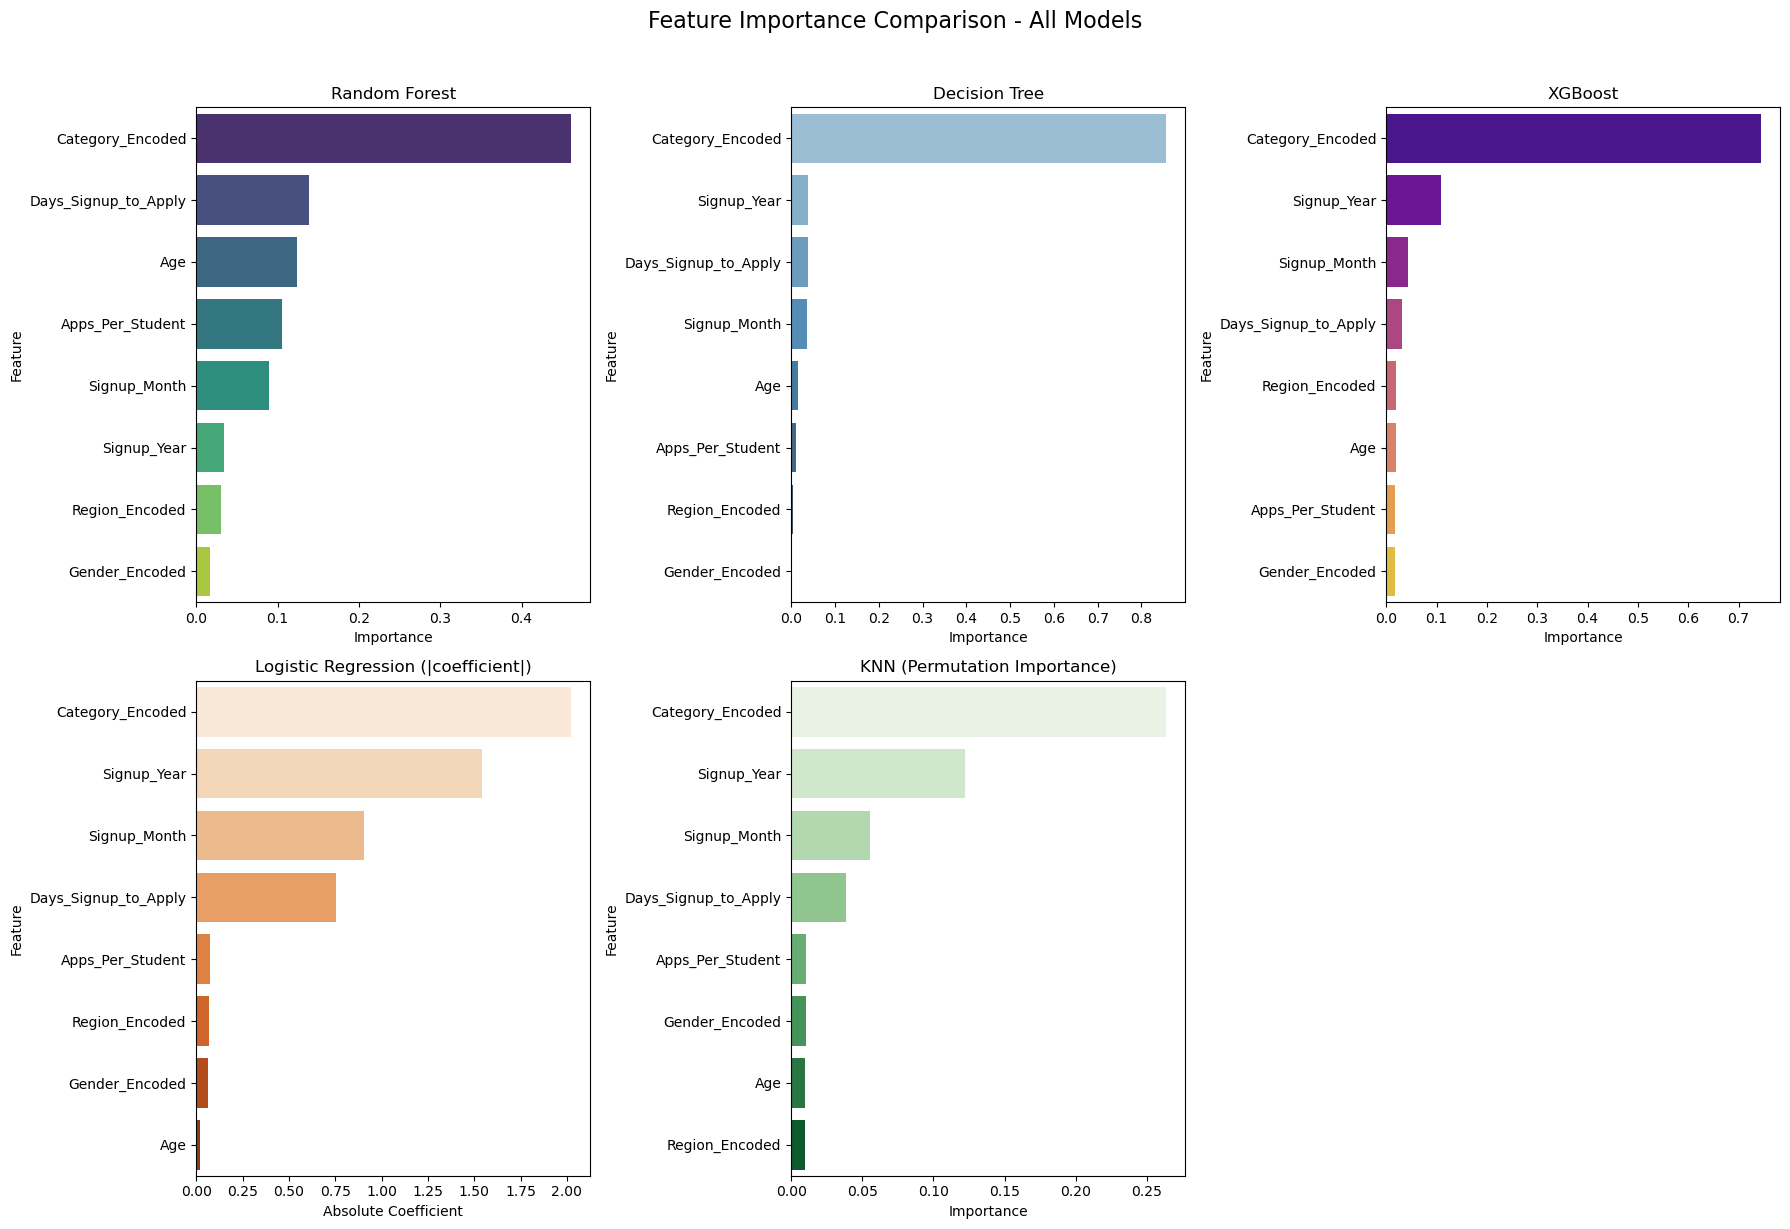


=== Feature Importance Tables ===

Random Forest:
                Feature  Importance
0      Category_Encoded      0.4610
4  Days_Signup_to_Apply      0.1384
3                   Age      0.1236
5      Apps_Per_Student      0.1059
6          Signup_Month      0.0891
7           Signup_Year      0.0343
1        Region_Encoded      0.0307
2        Gender_Encoded      0.0170

Decision Tree:
                Feature  Importance
0      Category_Encoded      0.8566
7           Signup_Year      0.0382
4  Days_Signup_to_Apply      0.0378
6          Signup_Month      0.0362
3                   Age      0.0154
5      Apps_Per_Student      0.0115
1        Region_Encoded      0.0035
2        Gender_Encoded      0.0009

XGBoost:
                Feature  Importance
0      Category_Encoded      0.7451
7           Signup_Year      0.1080
6          Signup_Month      0.0425
4  Days_Signup_to_Apply      0.0309
1        Region_Encoded      0.0196
3                   Age      0.0195
5      Apps_Per_Student

In [23]:
# Feature Importance Comparison - All Models
from sklearn.inspection import permutation_importance

# 1. Random Forest (built-in)
rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False)

# 2. Decision Tree (built-in)
dt_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': models['Decision Tree'].feature_importances_
}).sort_values('Importance', ascending=False)

# 3. XGBoost (built-in)
xgb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': models['XGBoost'].feature_importances_
}).sort_values('Importance', ascending=False)

# 4. Logistic Regression (absolute coefficients)
lr_model = models['Logistic Regression']
lr_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': np.abs(lr_model.coef_[0])
}).sort_values('Importance', ascending=False)

# 5. KNN (permutation importance)
knn_model = models['KNN']
# Compute permutation importance on test set
perm_importance = permutation_importance(knn_model, X_test_scaled, y_test, 
                                         n_repeats=10, random_state=42)
knn_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=False)

# Plot all five in a 2x3 grid (one empty subplot)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Random Forest
sns.barplot(data=rf_importance, x='Importance', y='Feature', ax=axes[0], palette='viridis')
axes[0].set_title('Random Forest', fontsize=12)
axes[0].set_xlabel('Importance')

# Decision Tree
sns.barplot(data=dt_importance, x='Importance', y='Feature', ax=axes[1], palette='Blues_d')
axes[1].set_title('Decision Tree', fontsize=12)
axes[1].set_xlabel('Importance')

# XGBoost
sns.barplot(data=xgb_importance, x='Importance', y='Feature', ax=axes[2], palette='plasma')
axes[2].set_title('XGBoost', fontsize=12)
axes[2].set_xlabel('Importance')

# Logistic Regression (absolute coefficients)
sns.barplot(data=lr_importance, x='Importance', y='Feature', ax=axes[3], palette='Oranges')
axes[3].set_title('Logistic Regression (|coefficient|)', fontsize=12)
axes[3].set_xlabel('Absolute Coefficient')

# KNN (permutation importance)
sns.barplot(data=knn_importance, x='Importance', y='Feature', ax=axes[4], palette='Greens')
axes[4].set_title('KNN (Permutation Importance)', fontsize=12)
axes[4].set_xlabel('Importance')

# Hide the last empty subplot
axes[5].axis('off')

plt.suptitle('Feature Importance Comparison - All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Print the importance tables
print("\n=== Feature Importance Tables ===\n")
print("Random Forest:")
print(rf_importance.round(4))
print("\nDecision Tree:")
print(dt_importance.round(4))
print("\nXGBoost:")
print(xgb_importance.round(4))
print("\nLogistic Regression (|coef|):")
print(lr_importance.round(4))
print("\nKNN (Permutation Importance):")
print(knn_importance.round(4))

In [25]:
# Model Performance Table
print("\n=== Model Performance ===\n")
print(results_df.round(4))

# Best model
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_model = models[best_model_name]
print(f"\n Best Model: {best_model_name}")
print(f"   F1-Score: {results_df.loc[results_df['F1-Score'].idxmax(), 'F1-Score'].round(4)}")
print(f"   ROC-AUC: {results_df.loc[results_df['ROC-AUC'].idxmax(), 'ROC-AUC'].round(4)}")


=== Model Performance ===

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8560     0.9120  0.7736    0.8371   0.8985
1                  KNN    0.8347     0.8521  0.7919    0.8209   0.9000
2        Decision Tree    0.8528     0.9038  0.7749    0.8344   0.9128
3        Random Forest    0.8447     0.8477  0.8233    0.8353   0.9194
4              XGBoost    0.8610     0.9169  0.7801    0.8430   0.9296

 Best Model: XGBoost
   F1-Score: 0.843
   ROC-AUC: 0.9296
